In [1]:
import pandas as pd
import numpy as np

### Process Raw Dispatch Data

In [2]:
PATH = 'data/OriginalDatosDispatch.csv'
df_trucks = pd.read_csv(PATH, encoding='utf-8', sep=';', decimal=',')

In [7]:
df_trucks.head(5).T

,0,1,2,3,4,5,6,7,8,9
shiftid,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0,240326001.0
fullshiftname,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A,26-MAR-2024 A
shiftname,240326a,240326a,240326a,240326a,240326a,240326a,240326a,240326a,240326a,240326a
truck,CA94,CA87,CA105,CA57,CA86,CA60,CA81,CA88,CA98,CA58
excav,PA03,PA11,PA05,PA11,BH09,BH12,PA11,CF11,BH09,BH12
grade,F11W-3320-13/ES1,F11W-3290-01/ES1,F9SE-3020-64/BL1,F11W-3290-01/ES1,F9SE-3020-16/BP3,F11W-3305-09/ES1,F11W-3290-01/ES1,F11W-3320-13/ES1,F9SE-3020-16/BP3,F11W-3305-09/ES1
loadlocation,F11W-3320-13,F11W-3290-01,F9SE-3020-64,F11W-3290-01,F9SE-3020-16,F11W-3305-09,F11W-3290-01,F11W-3320-13/C,F9SE-3020-16,F11W-3305-09
loadlocationunit,Disparo,Disparo,Disparo,Disparo,Disparo,Disparo,Disparo,Disparo,Disparo,Disparo
tons,309.0,309.0,288.0,291.0,329.0,303.0,290.0,300.0,305.0,264.0
trucksize,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0


: 

In [4]:
# First remap
current_activities = ['assigntimestamp (carga)', 'arrivetimestamp (carga)', 'spottingtimestamp (carga)',
  'loadingtimestamp (carga)', 'fulltimestamp (carga)', 'assigntimestamp (descarga)',
  'arrivetimestamp (descarga)', 'dumpingtimestamp (descarga)', 'emptytimestamp (descarga)']
mapped_activities = ['Assign Carga', 'Arrive Carga', 'Spotting Carga', 'Loading Carga', 'FullTime Carga',
                     'Assign Descarga', 'Arrive Descarga', 'Dumping Descarga', 'Empty Descarga']
ACTIVITY_MAP = dict(zip(current_activities, mapped_activities))
ACTIVITY_MAP

{'assigntimestamp (carga)': 'Assign Carga',
 'arrivetimestamp (carga)': 'Arrive Carga',
 'spottingtimestamp (carga)': 'Spotting Carga',
 'loadingtimestamp (carga)': 'Loading Carga',
 'fulltimestamp (carga)': 'FullTime Carga',
 'assigntimestamp (descarga)': 'Assign Descarga',
 'arrivetimestamp (descarga)': 'Arrive Descarga',
 'dumpingtimestamp (descarga)': 'Dumping Descarga',
 'emptytimestamp (descarga)': 'Empty Descarga'}

In [23]:
example_df = df_trucks.reset_index().rename(columns={'index': 'id'})
example_df = example_df.rename(columns=ACTIVITY_MAP)
id_column = 'id'
resource_column = 'truckoperatorname'
common_columns = ['crew', 'shiftid', 'loadlocation', 'loadlocationunit', 'grade', 'excav', 'truck', 'dumplocation', 'dumplocationunit']
additional_columns = ['totaldistance (carga)', 'totaldistance (descarga)']
additional_columns_renamed = ['total_distance_carga', 'total_distance_descarga']
additional_columns_dict = dict(zip(additional_columns, additional_columns_renamed))
df_pivot = pd.melt(example_df, id_vars=[id_column, resource_column, *common_columns, *additional_columns], value_vars=mapped_activities)
df_pivot = df_pivot.rename(columns={'value': 'timestamp', resource_column: 'resource', 'variable': 'activity', id_column: 'case_id', **additional_columns_dict})
# Convert columns for better formatting
df_pivot['resource'] = df_pivot['resource'].str.title()
df_pivot['case_id'] = df_pivot['case_id'].astype(int).astype(str)
df_pivot['timestamp'] = pd.to_datetime(df_pivot['timestamp'])
df_pivot['timestamp'] = df_pivot['timestamp'].dt.tz_localize(None)
activities_to_add_ms = ['Assign Carga', 'Spotting Carga', 'Assign Descarga', 'Dumping Descarga']

df_pivot['timestamp'] = np.where(
  df_pivot['activity'].isin(activities_to_add_ms),
  df_pivot['timestamp'] + pd.Timedelta(value=100, unit='ms'),
  df_pivot['timestamp'] - pd.Timedelta(value=100, unit='ms')
)
df_pivot = df_pivot[['case_id', 'activity', 'timestamp', 'resource', *common_columns, *additional_columns_renamed]]
df_pivot = df_pivot.sort_values('case_id').reset_index(drop=True)

# See the data sparcity, and filter cases where timestamp is null
timestamp_null_cases = df_pivot[df_pivot['timestamp'].isnull()]['case_id'].unique()
print(f'There are {len(timestamp_null_cases)} cases where there are missing timestamps')
df_pivot = df_pivot[~df_pivot['case_id'].isin(timestamp_null_cases)]

# Default order for activities that have the same timestamp
indexed_activity = [*enumerate(mapped_activities)]
sorted_activities = pd.DataFrame(indexed_activity, columns=['activity_index', 'activity'])
df_pivot = df_pivot.merge(sorted_activities, left_on='activity', right_on='activity')
df_pivot = df_pivot.sort_values(['case_id', 'activity_index'])
df_pivot = df_pivot.drop('activity_index', axis=1)

# Get the parsed grade and loadlocation
position_columns = ['excav', 'loadlocation', 'truck', 'shiftid']
df_pivot['excav'] = df_pivot['excav'].astype(str).str[0:2]
df_pivot['loadlocation'] = df_pivot['loadlocation'].astype(str).str.extract(r'([a-zA-Z]\d{1,2}|STOC|CUBICULOS-ENAEX)')[0]

There are 2940 cases where there are missing timestamps


In [24]:
# Not fix the way that activities are sorted according to Ignacio notebook
atomic_activities = ['Assign Carga', 'Arrive Carga', 'Assign Descarga', 'Arrive Descarga']
df_pivot_atomic = df_pivot[df_pivot['activity'].isin(atomic_activities)]
df_pivot_atomic['timestamp_end'] = df_pivot_atomic['timestamp']

departure_activities = ['Spotting Carga', 'FullTime Carga']
return_activities = ['Dumping Descarga', 'Empty Descarga']

def make_between_time(df: pd.DataFrame, activities = list[str]) -> pd.DataFrame:
  """
    Calculate the time difference between activities and create the "timestamp_end" column, then remove the last activity
  """
  df_range = df[df['activity'].isin(activities)]
  series_diff_time = df_range.groupby('case_id')['timestamp'].diff().shift(-1).fillna(pd.Timedelta(0))
  df_range.loc[:,'timestamp_end'] = df_range['timestamp'] + series_diff_time
  return df_range[df_range['activity'] != activities[-1]]

# df_departure = df_pivot[df_pivot['activity'].isin(departure_activities)]
# series_diff_time = df_departure.groupby('case_id')['timestamp'].diff().shift(-1).fillna(pd.Timedelta(0))
# df_departure['timestamp_end'] = df_departure['timestamp'] + series_diff_time

df_departure = make_between_time(df_pivot, departure_activities)
df_return = make_between_time(df_pivot, return_activities)
df_total = pd.concat([df_pivot_atomic, df_departure, df_return]).sort_values(by=['case_id', 'timestamp'])

/tmp/ipykernel_22302/4013920225.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pivot_atomic['timestamp_end'] = df_pivot_atomic['timestamp']
/tmp/ipykernel_22302/4013920225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_range.loc[:,'timestamp_end'] = df_range['timestamp'] + series_diff_time
/tmp/ipykernel_22302/4013920225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [25]:
map_new_truck_activities = {
  'Assign Carga': 'Asignación carga',
  'Arrive Carga': 'Fin traslado a carga',
  'Spotting Carga': 'Carga',
  'Assign Descarga': 'Asignación descarga',
  'Arrive Descarga': 'Fin traslado a descarga',
  'Dumping Descarga': 'Descarga',
}
df_total['activity'] = df_total['activity'].map(map_new_truck_activities)

In [27]:
resumed_truck_activities = map_new_truck_activities.values()
df_total['activity'] = pd.Categorical(df_total['activity'],
                                      ordered=True,
                                      categories=resumed_truck_activities)

In [28]:
print(df_total.columns.tolist())

['case_id', 'activity', 'timestamp', 'resource', 'crew', 'shiftid', 'loadlocation', 'loadlocationunit', 'grade', 'excav', 'truck', 'dumplocation', 'dumplocationunit', 'total_distance_carga', 'total_distance_descarga', 'timestamp_end']


In [29]:
df_log_trucks = df_total.copy().sort_values(by=['case_id', 'timestamp'])
# keep the case_id of the cycle or transaction of the truck (load - download cycle)
df_log_trucks['cycle_id'] = df_log_trucks['case_id']
# case_id as the truck
df_log_trucks['case_id'] = df_log_trucks['truck']
# df_log_trucks = df_log_trucks.sort_values(by=['cycle_id', 'timestamp'])
# df_log_trucks['diff'] = df_log_trucks.groupby(by=['cycle_id'])['timestamp'].diff().shift(-1)
# df_log_trucks['timestamp_end'] = df_log_trucks['timestamp'] + df_log_trucks['diff']
# df_log_trucks = df_log_trucks.sort_values(by=['case_id', 'timestamp'])

In [30]:
df_log_trucks['activity'].unique()

['Inicio traslado a carga', 'Fin traslado a carga', 'Carga', 'Inicio traslado a descarga', 'Fin traslado a descarga', 'Descarga']
Categories (6, object): ['Inicio traslado a carga' < 'Fin traslado a carga' < 'Carga' < 'Inicio traslado a descarga' < 'Fin traslado a descarga' < 'Descarga']

#### Process Raw contingency activities

In [31]:
df_contingencies = pd.read_csv('data/ContingencyData.csv', parse_dates=['timestamp'])
df_mapped_stop_reason = pd.read_csv('data/mapped_stop_reasons.csv')
map_contingencies_activities = df_mapped_stop_reason[['stop_reason', 'grouped']].set_index('stop_reason').to_dict()['grouped']

In [33]:
df_contingencies.head()

,id,fieldid,shiftid,timestamp,duration,truck_id,stop_code,stop_reason,status_id,status_name
0,2403010010013562888,03:25:55,240301001,2024-03-01 00:25:55,3355,CA69,314,SIN OPERADOR / FUERA DE FAENA,225,Reserva
1,2403010010027900092,07:34:03,240301001,2024-03-01 04:34:03,1389,CA52,314,SIN OPERADOR / FUERA DE FAENA,225,Reserva
2,2403010010035685160,05:00:00,240301001,2024-03-01 02:00:00,17621,CA103,406,Pinchazo o rotura neumaticos,223,Mantencion
3,2403010010036416468,09:53:41,240301001,2024-03-01 06:53:41,2464,CA103,423,Reparacion equipo accidentado,223,Mantencion
4,2403010020000034568,00:00:00,240301002,2024-03-01 09:00:00,997,CA101,246,Cambio de turno,226,Demora


In [34]:
from pm_pd_utils import squeeze_consecutive_activities

df_cont = df_contingencies.copy()
df_cont['timestamp_end'] = df_cont['timestamp'] + pd.to_timedelta(df_cont['duration'], unit='seconds')
df_cont = df_cont.rename(columns={'truck_id': 'case_id', 'stop_reason': 'activity'})
df_cont['activity'] = df_cont['activity'].map(map_contingencies_activities)
df_cont = df_cont.drop(columns=['fieldid', 'duration', 'stop_code', 'status_name', 'status_id'])
df_cont = df_cont.drop(columns=['id'])
df_cont = df_cont[['case_id', 'activity', 'timestamp', 'timestamp_end', 'shiftid']]
df_cont = squeeze_consecutive_activities(df_cont, ['shiftid']).reset_index(drop=True)
df_cont = df_cont[~df_cont['activity'].isin(['Efectivo'])].sort_values(by=['case_id', 'timestamp'])
df_cont.head()

,case_id,activity,timestamp,timestamp_end,shiftid
55513,CA100,Pista obstruida,2024-02-27 12:30:40,2024-02-27 12:34:55,240227002
55510,CA100,Sin equipo de carguio,2024-02-27 13:01:19,2024-02-27 13:04:09,240227002
55511,CA100,Colacion comedor,2024-02-27 13:13:36,2024-02-27 13:34:17,240227002
56033,CA100,Otra demora,2024-02-27 13:42:44,2024-02-27 13:48:46,240227002
56032,CA100,Sin equipo de carguio,2024-02-27 13:50:13,2024-02-27 14:00:33,240227002


In [44]:
# Explore a single truck turn
df_cont[(df_cont['shiftid'] == 240312002) & (df_cont['case_id'] == 'CA100')]

,case_id,activity,timestamp,timestamp_end,shiftid
37254,CA100,Pista obstruida,2024-03-12 10:10:24,2024-03-12 10:24:08,240312002
37252,CA100,Pista obstruida,2024-03-12 10:12:41,2024-03-12 10:13:03,240312002
37250,CA100,Operador fuera del equipo,2024-03-12 11:32:00,2024-03-12 11:32:39,240312002
37256,CA100,Carga de combustible,2024-03-12 12:24:56,2024-03-12 12:33:20,240312002
37258,CA100,Mantencion imprevista,2024-03-12 12:50:33,2024-03-12 13:55:13,240312002
37740,CA100,Pista obstruida,2024-03-12 14:01:58,2024-03-12 14:03:49,240312002
37741,CA100,Sin equipo de carguio,2024-03-12 14:04:37,2024-03-12 14:28:23,240312002
37748,CA100,Sin equipo de carguio,2024-03-12 14:45:30,2024-03-12 14:59:40,240312002
37747,CA100,Colacion comedor,2024-03-12 15:21:02,2024-03-12 16:22:10,240312002
37743,CA100,Carga de combustible,2024-03-12 16:27:58,2024-03-12 16:28:08,240312002


#### Join both dataframes

In [36]:
df_log_trucks.head()

,case_id,activity,timestamp,resource,crew,shiftid,loadlocation,loadlocationunit,grade,excav,truck,dumplocation,dumplocationunit,total_distance_carga,total_distance_descarga,timestamp_end,cycle_id
0,CA94,Inicio traslado a carga,2024-03-26 07:58:02.100,Darwin Orellana Rojo,G4,240326001.0,F11,Disparo,F11W-3320-13/ES1,PA,CA94,BOT-HUA-3680/B,Botadero,6165.0,6165,2024-03-26 07:58:02.100,0
5,CA94,Fin traslado a carga,2024-03-26 08:07:38.900,Darwin Orellana Rojo,G4,240326001.0,F11,Disparo,F11W-3320-13/ES1,PA,CA94,BOT-HUA-3680/B,Botadero,6165.0,6165,2024-03-26 08:07:38.900,0
2,CA94,Carga,2024-03-26 08:07:39.100,Darwin Orellana Rojo,G4,240326001.0,F11,Disparo,F11W-3320-13/ES1,PA,CA94,BOT-HUA-3680/B,Botadero,6165.0,6165,2024-03-26 08:19:28.900,0
3,CA94,Inicio traslado a descarga,2024-03-26 08:19:29.100,Darwin Orellana Rojo,G4,240326001.0,F11,Disparo,F11W-3320-13/ES1,PA,CA94,BOT-HUA-3680/B,Botadero,6165.0,6165,2024-03-26 08:19:29.100,0
4,CA94,Fin traslado a descarga,2024-03-26 08:44:53.900,Darwin Orellana Rojo,G4,240326001.0,F11,Disparo,F11W-3320-13/ES1,PA,CA94,BOT-HUA-3680/B,Botadero,6165.0,6165,2024-03-26 08:44:53.900,0


In [37]:
# map_activities = {
#   'Assign Carga': 'Traslado a carga',
#   'Spotting Carga': 'Carga',
#   'Assign Descarga': 'Traslado a descarga',
#   'Dumping Descarga': 'Descarga',
#   'Arrive Carga': 'Traslado a carga',
#   'Loading Carga': 'Carga',
#   'Arrive Descarga': 'Traslado a descarga',
#   'Empty Descarga': 'Descarga'
# }
# truck_activities = ['Traslado a carga', 'Carga', 'Traslado a descarga', 'Descarga']

df_trucks_final = df_log_trucks[['case_id', 'activity', 'timestamp', 'timestamp_end', 'shiftid']]
df_trucks_final['shiftid'] = df_trucks_final['shiftid'].astype(int)
# df_trucks_final = df_trucks_final[df_trucks_final['activity'] != 'FullTime Carga']
# df_trucks_final['activity'] = pd.Categorical(df_trucks_final['activity'].map(map_activities), categories=truck_activities, ordered=True)
df_trucks_final = df_trucks_final.sort_values(by=['case_id', 'timestamp', 'activity'])

/tmp/ipykernel_22302/1980061654.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trucks_final['shiftid'] = df_trucks_final['shiftid'].astype(int)


In [38]:
df_trucks_final.head()

,case_id,activity,timestamp,timestamp_end,shiftid
310502,CA100,Inicio traslado a carga,2024-02-25 21:51:12.100,2024-02-25 21:51:12.100,240226001
310504,CA100,Fin traslado a carga,2024-02-25 22:01:14.900,2024-02-25 22:01:14.900,240226001
310505,CA100,Carga,2024-02-25 22:01:15.100,2024-02-25 22:02:37.900,240226001
310506,CA100,Inicio traslado a descarga,2024-02-25 22:02:38.100,2024-02-25 22:02:38.100,240226001
310500,CA100,Fin traslado a descarga,2024-02-25 22:26:35.900,2024-02-25 22:26:35.900,240226001


In [39]:
from pm_pd_utils import find_valid_datetime_range

df_full = pd.concat([df_trucks_final, df_cont])
activities = [*resumed_truck_activities, *df_cont['activity'].unique().tolist()]
df_full['activity'] = pd.Categorical(df_full['activity'], ordered=True, categories=activities)
df_full = df_full.sort_values(by=['case_id', 'timestamp', 'activity'])
# Fix the min time and max time
time_start, time_end = find_valid_datetime_range(df_log_trucks, df_cont)
df_full = df_full[(df_full['timestamp'] > time_start) & (df_full['timestamp_end'] < time_end)]
df_full = df_full.sort_values(by=['case_id', 'timestamp', 'activity'])
df_full = squeeze_consecutive_activities(df_full)

In [40]:
SAVE = False
if SAVE:
  df_full.to_csv('data/full_event_log_v4.csv', index=False)

In [50]:
import mpdfg

format_dictionary = {
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'start_timestamp': 'timestamp',
    'time:timestamp': 'timestamp_end',
    'cost:total': '',
    'org:resource': '',
}

taken_activities = resumed_truck_activities.copy()
df_subset = df_full.copy()
df_subset = squeeze_consecutive_activities(df_subset)
df_subset['activity'] = df_subset['activity'].astype(object)
event_log = mpdfg.log_formatter(log=df_subset, format=format_dictionary)

In [51]:
df_subset.head()

,case_id,activity,timestamp,timestamp_end,shiftid
0,CA100,Fin traslado a carga,2024-02-27 11:13:44.900,2024-02-27 11:13:44.900,240227002
1,CA100,Carga,2024-02-27 11:13:45.100,2024-02-27 11:16:35.900,240227002
2,CA100,Inicio traslado a descarga,2024-02-27 11:16:36.100,2024-02-27 11:16:36.100,240227002
3,CA100,Fin traslado a descarga,2024-02-27 11:39:47.900,2024-02-27 11:39:47.900,240227002
4,CA100,Descarga,2024-02-27 11:39:48.100,2024-02-27 11:41:36.900,240227002


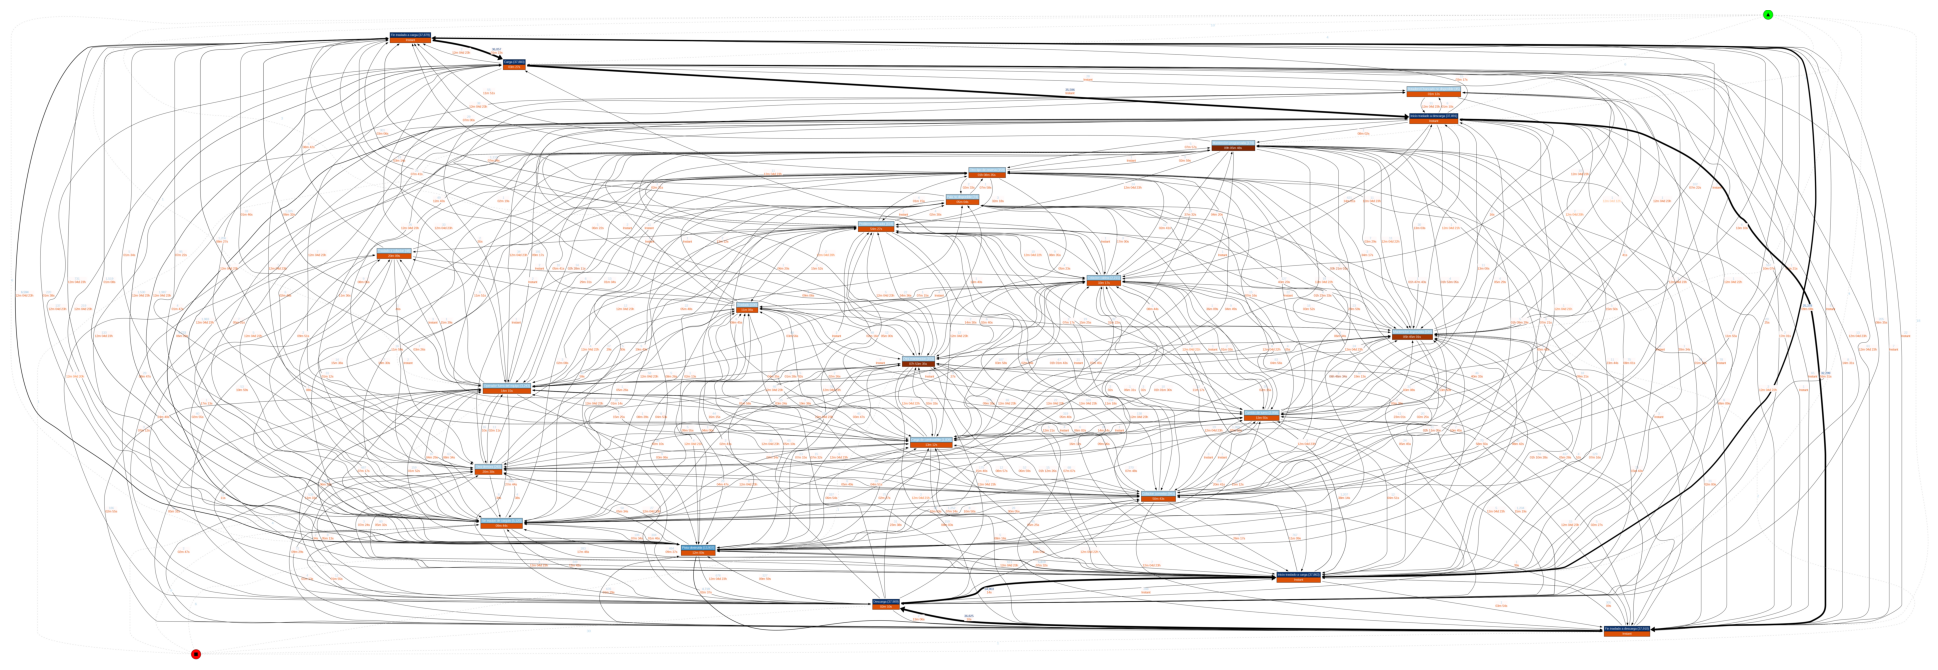

In [52]:
dfg, start_activities, end_activities = mpdfg.discover_multi_perspective_dfg(log=event_log, calculate_cost=False)
mpdfg.view_multi_perspective_dfg(dfg, start_activities, end_activities)

In [59]:
import seaborn as sns

<Axes: >

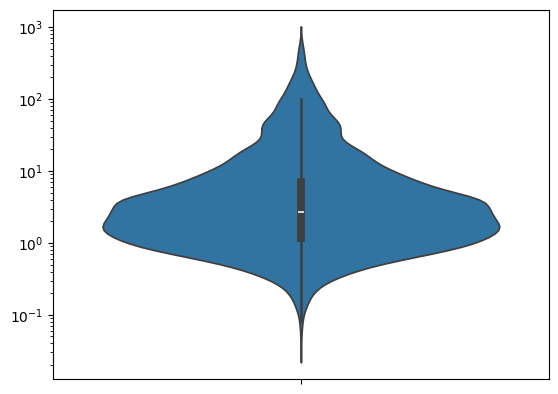

In [61]:
df_full_pista = df_full[df_full['activity'] == 'Pista obstruida']
delta_times = ((df_full_pista['timestamp_end'] - df_full_pista['timestamp']).dt.total_seconds() / 60)
sns.violinplot(data=delta_times, log_scale=True);

1.7666666666666666


<Axes: >

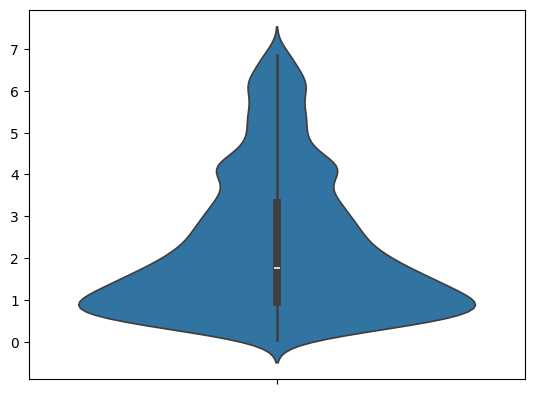

In [73]:
print(delta_times[delta_times < np.percentile(delta_times, 75)].median())
sns.violinplot(data=delta_times[delta_times < np.percentile(delta_times, 75)]);